**Assignment 3**

Michael Webster

- Additional experiments on the SCAN dataset
  - Fine-tuning using T-5 small model on exp 1b and 2
  - Curriculum learning on exp2
  - Chain of thought reasoning on exp2

## Setup

In [ ]:
#If running on colab
#!git clone https://github.com/michaelwebbie/ATNLP_Group5.git
#%cd /content/ATNLP_Group5

Cloning into 'ATNLP_Group5'...
remote: Enumerating objects: 67, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 67 (delta 22), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (67/67), 272.71 KiB | 3.45 MiB/s, done.
Resolving deltas: 100% (22/22), done.
/content/ATNLP_Group5


In [ ]:
!git clone https://github.com/brendenlake/SCAN.git

Cloning into 'SCAN'...
remote: Enumerating objects: 205, done.
remote: Total 205 (delta 0), reused 0 (delta 0), pack-reused 205 (from 1)
Receiving objects: 100% (205/205), 11.10 MiB | 31.93 MiB/s, done.
Resolving deltas: 100% (173/173), done.


In [ ]:
from Scripts.dataloader import load_pairs, load_command_list, commands_to_pairs
from Scripts.metrics import token_accuracy, sequence_accuracy, token_accuracy_exp1

import re
import math
import random
from dataclasses import dataclass
from collections import defaultdict
from typing import Dict, List, Tuple

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    get_linear_schedule_with_warmup,
)
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
all_pairs = load_pairs("SCAN/tasks.txt")
print(len(all_pairs))

20910


In [ ]:
cmd_to_pair = {src: (src, tgt) for src, tgt in all_pairs}

In [ ]:
def ids_to_action_str(id_seq, vocab, pad_idx, eos_idx):
    """Convert a list of action ids into a space-separated action string."""
    toks = []
    for i in id_seq:
        if i == eos_idx:
            break
        if i == pad_idx:
            continue
        toks.append(vocab.itos.get(i, "<UNK>"))
    return " ".join(toks)

In [ ]:
def text_to_action_ids(action_text, vocab):
    """
    Convert a space-separated action string (e.g. 'I_WALK I_RUN')
    into a list of token IDs, including the EOS token.
    """
    tokens = action_text.strip().split()
    ids = []

    for tok in tokens:
        tok_id = vocab.stoi.get(tok, vocab.stoi.get("<UNK>"))
        ids.append(tok_id)

    # append EOS
    ids.append(vocab.stoi["<EOS>"])

    return ids

### Normalising SCAN actions

In [ ]:
_ACTION_TOKEN_RE = re.compile(r"[A-Z_]+")

def _fix_turn_tokens(tokens: List[str]) -> List[str]:
    """
    SCAN has 'TURN LEFT' as two tokens. Collapse this into a single action token: 'I_TURN_LEFT'.
    """
    out = []
    i = 0
    while i < len(tokens):
        if i + 1 < len(tokens) and tokens[i] == "TURN" and tokens[i + 1] in ("LEFT", "RIGHT"):
            out.append(f"I_TURN_{tokens[i + 1]}")
            i += 2
        else:
            out.append(tokens[i])
            i += 1
    return out

def normalize_actions(action_str: str) -> str:
    """
    Take a raw SCAN action string and return a cleaned, space-separated sequence of action tokens.
    Example input:  'TURN LEFT JUMP TURN LEFT JUMP'
    Example output: 'I_TURN_LEFT JUMP I_TURN_LEFT JUMP'
    """
    toks = _ACTION_TOKEN_RE.findall(action_str.upper())
    toks = _fix_turn_tokens(toks)
    return " ".join(toks).strip()

def gold_to_action_tokens(gold_action_str: str) -> List[str]:
    """
    Normalise a gold action string and return list of tokens.
    """
    norm = normalize_actions(gold_action_str)
    return norm.split() if norm else []

def decode_to_action_tokens(decoded_text: str) -> List[str]:
    """
    Normalise a decoded model string and return list of tokens.
    """
    norm = normalize_actions(decoded_text)
    return norm.split() if norm else []

### Build minimal vocab for evaluation

In [ ]:
class ActionVocab:
    """
    Minimal vocab mapping SCAN action tokens to ids.
    """
    def __init__(self):
        self.stoi = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}

    def add_tokens(self, toks: List[str]):
        for t in toks:
            if t not in self.stoi:
                idx = len(self.stoi)
                self.stoi[t] = idx
                self.itos[idx] = t

def build_action_vocab_from_target_texts(target_texts: List[str]) -> ActionVocab:
    v = ActionVocab()
    for t in target_texts:
        v.add_tokens(gold_to_action_tokens(t))
    return v

def tokens_to_ids(tokens: List[str], vocab: ActionVocab) -> List[int]:
    return [vocab.stoi.get(t, vocab.stoi["<UNK>"]) for t in tokens]

def gold_text_to_ids(gold_text: str, vocab: ActionVocab) -> List[int]:
    ids = tokens_to_ids(gold_to_action_tokens(gold_text), vocab)
    ids.append(vocab.stoi["<EOS>"])
    return ids

### Build dataset for fine-tuning

In [ ]:
@dataclass
class ScanTextExample:
    source_text: str
    target_text: str

class ScanHFDataset(Dataset):
    """
    returns:
      - source_text: input command with prefix
      - target_text: normalised action sequence
    """
    def __init__(
        self,
        pairs: List[Tuple[str, str]],
        source_prefix: str = "translate command to actions: ",
        normalize_target: bool = True,
    ):
        self.examples: List[ScanTextExample] = []
        for src, tgt in pairs:
            src_txt = f"{source_prefix}{src.strip()}"
            tgt_norm = normalize_actions(tgt) if normalize_target else tgt.strip()
            self.examples.append(ScanTextExample(src_txt, tgt_norm))

    def __len__(self) -> int:
        return len(self.examples)

    def __getitem__(self, idx: int) -> Dict[str, str]:
        ex = self.examples[idx]
        return {"source_text": ex.source_text, "target_text": ex.target_text}


def build_scan_hf_datasets_simple(
    train_file: str,
    test_file: str,
    cmd_to_pair: Dict[str, Tuple[str, str]],
    source_prefix: str = "translate command to actions: ",
):
    """
    Build train/test HF datasets for Exp1b from SCAN split files.
    """
    train_cmds = load_command_list(train_file)
    test_cmds  = load_command_list(test_file)

    train_pairs = commands_to_pairs(train_cmds, cmd_to_pair)
    test_pairs  = commands_to_pairs(test_cmds,  cmd_to_pair)

    train_ds = ScanHFDataset(train_pairs, source_prefix=source_prefix, normalize_target=True)
    test_ds  = ScanHFDataset(test_pairs,  source_prefix=source_prefix, normalize_target=True)

    return train_ds, test_ds, train_pairs, test_pairs

### Chain of thought target format
- Inspired from Wei et al 2022

In [ ]:
COT_PREFIX = "Reasoning:"

def make_cot_input(command_text: str,
                   source_prefix: str = "translate command to actions: ") -> str:
    """
    Wei-style CoT for SCAN:
    - Keep the *target* as pure actions.
    - Augment the *input* with a short, deterministic natural-language
      explanation of how to execute the command.

    Example output (single string):
      'translate command to actions: jump around left twice
       Reasoning: we decompose the command ... "twice" means ...'
    """
    cmd = command_text.strip()
    cmd_lc = cmd.lower()

    parts = [f"{source_prefix}{cmd}",
             f"{COT_PREFIX} we decompose the command into simpler sub-commands and modifiers."]


    if " after " in cmd_lc:
        left, right = cmd_lc.split(" after ", 1)
        parts.append(
            f' "after" means we execute "{right.strip()}" first and then "{left.strip()}".'
        )
    elif " and " in cmd_lc:
        sub_cmds = [p.strip() for p in cmd_lc.split(" and ")]
        if len(sub_cmds) > 1:
            parts.append(
                " 'and' means we execute the sub-commands in order: "
                + " then ".join(f'"{p}"' for p in sub_cmds) + "."
            )


    if " around left" in cmd_lc:
        parts.append(
            " 'around left' means repeatedly turning left and applying the base action in a loop."
        )
    if " around right" in cmd_lc:
        parts.append(
            " 'around right' means repeatedly turning right and applying the base action in a loop."
        )
    if " opposite left" in cmd_lc:
        parts.append(
            " 'opposite left' means turning left twice (180 degrees) before executing the base action."
        )
    if " opposite right" in cmd_lc:
        parts.append(
            " 'opposite right' means turning right twice (180 degrees) before executing the base action."
        )

    if "twice" in cmd_lc:
        parts.append(" 'twice' means repeating the described movement pattern two times.")
    if "thrice" in cmd_lc:
        parts.append(" 'thrice' means repeating the described movement pattern three times.")

    primitives = [v for v in ["walk", "run", "jump", "look"] if v in cmd_lc]
    if primitives:
        parts.append(
            " The primitive verbs "
            + ", ".join(primitives)
            + " map directly to their atomic movement actions."
        )

    if "turn left" in cmd_lc:
        parts.append(" 'turn left' rotates the agent 90 degrees to the left without moving.")
    if "turn right" in cmd_lc:
        parts.append(" 'turn right' rotates the agent 90 degrees to the right without moving.")

    if len(parts) == 2:
        parts.append(" We follow the SCAN grammar to map the command compositionally to actions.")

    return " ".join(parts)

def extract_actions_from_decoded(text, action_vocab):
    """
    Extract the action sequence from a decoded model output.

    Expected formats:
      1) "PLAN: ... ACTIONS: I_WALK I_RUN ..."
      2) "I_WALK I_RUN ..."  (no CoT at inference)
    """
    text = text.strip()

    if "ACTIONS:" in text:
        actions_part = text.split("ACTIONS:", 1)[1].strip()
        return " ".join(actions_part.split())

    toks = text.split()
    action_toks = [t for t in toks if t in action_vocab.stoi]

    if action_toks:
        return " ".join(action_toks)
    return ""


### Build dataset for CoT loop

In [ ]:
@dataclass
class ScanTextExampleCoT:
    source_text: str
    target_text: str
    act_len: int
    command_text: str

class ScanHFDatasetCoT(Dataset):
    """
    Dataset for Exp2 that stores:
      - source_text: command (+ optional CoT reasoning)
      - target_text: always pure actions
      - act_len:     length of gold action sequence (for curriculum)
      - command_text: raw command (for analysis)
    """
    def __init__(
        self,
        pairs: List[Tuple[str, str]],
        source_prefix: str = "translate command to actions: ",
        normalize_target: bool = True,
        use_cot: bool = True,
    ):
        self.examples: List[ScanTextExampleCoT] = []
        for src, tgt in pairs:
            cmd = src.strip()

            if use_cot:
                src_txt = make_cot_input(cmd, source_prefix=source_prefix)
            else:
                src_txt = f"{source_prefix}{cmd}"

            tgt_norm = normalize_actions(tgt) if normalize_target else tgt.strip()
            act_len = len(gold_to_action_tokens(tgt_norm))
            tgt_txt = tgt_norm

            self.examples.append(
                ScanTextExampleCoT(
                    source_text=src_txt,
                    target_text=tgt_txt,
                    act_len=act_len,
                    command_text=cmd,
                )
            )

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]
        return {
            "source_text": ex.source_text,
            "target_text": ex.target_text,
            "act_len": ex.act_len,
            "command_text": ex.command_text,
        }

def build_scan_hf_datasets_exp2_cot(
    train_file: str,
    test_file: str,
    cmd_to_pair: Dict[str, Tuple[str, str]],
    source_prefix: str = "translate command to actions: ",
    use_cot_train: bool = True,
    use_cot_test: bool = False,
):
    """
    Build train/test datasets for Exp2.

      - train_ds: if use_cot_train=True, the *input* (source_text) is augmented
        with a deterministic chain-of-thought explanation; targets are always
        pure action sequences.

      - test_ds: normally use_cot_test=False, so evaluation uses plain inputs
        and pure-action targets.
    """
    train_cmds = load_command_list(train_file)
    test_cmds  = load_command_list(test_file)

    train_pairs = commands_to_pairs(train_cmds, cmd_to_pair)
    test_pairs  = commands_to_pairs(test_cmds,  cmd_to_pair)

    train_ds = ScanHFDatasetCoT(
        train_pairs, source_prefix=source_prefix,
        normalize_target=True, use_cot=use_cot_train
    )
    test_ds  = ScanHFDatasetCoT(
        test_pairs,  source_prefix=source_prefix,
        normalize_target=True, use_cot=use_cot_test
    )

    return train_ds, test_ds, train_pairs, test_pairs


### Collators for tokenisation

In [ ]:
class T5Collator:
    """
    Collator for standard fine-tuning (Exp1b).
    Converts raw strings to token ids for T5.
    """
    def __init__(self, tokenizer, max_src_len=64, max_tgt_len=128):
        self.tok = tokenizer
        self.max_src_len = max_src_len
        self.max_tgt_len = max_tgt_len

    def __call__(self, batch):
        sources = [x["source_text"] for x in batch]
        targets = [x["target_text"] for x in batch]

        enc = self.tok(
            sources,
            max_length=self.max_src_len,
            truncation=True,
            padding=True,
            return_tensors="pt",
        )
        labels = self.tok(
            text_target=targets,
            max_length=self.max_tgt_len,
            truncation=True,
            padding=True,
            return_tensors="pt",
        )["input_ids"]
        labels[labels == self.tok.pad_token_id] = -100
        enc["labels"] = labels
        return enc

class T5CollatorSimple(T5Collator):
    """
    Same as T5Collator; separate name just to keep Exp2 code readable.
    """
    pass

### Generic fine-tuning loop (used for Exp1b)

In [ ]:
def finetune_t5(
    train_ds,
    model_name="t5-small",
    batch_size=64,
    lr=5e-4,
    num_epochs=10,
    max_src_len=64,
    max_tgt_len=128,
    warmup_ratio=0.01,
    grad_clip=1.0,
    use_amp=True,
):
    """
    Standard epoch-based fine-tuning for Exp1b.
    """
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

    loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=T5Collator(tokenizer, max_src_len, max_tgt_len),
    )

    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    total_steps = len(loader) * num_epochs
    warmup_steps = max(1, int(warmup_ratio * total_steps))
    sched = get_linear_schedule_with_warmup(opt, warmup_steps, total_steps)

    scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and device.type == "cuda"))

    for ep in range(1, num_epochs + 1):
        model.train()
        total_loss = 0.0
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            opt.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=(use_amp and device.type == "cuda")):
                loss = model(**batch).loss

            scaler.scale(loss).backward()
            if grad_clip is not None:
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            scaler.step(opt)
            scaler.update()
            sched.step()

            total_loss += loss.item()

        print(f"Epoch {ep:03d}/{num_epochs} | loss={total_loss/len(loader):.4f}")

    return model, tokenizer

### Curriculum fine-tuning loop for Exp2

In [ ]:
def infinite_loader(dl):
    """
    Simple generator that cycles through a DataLoader forever.
    """
    while True:
        for b in dl:
            yield b

def finetune_t5_curriculum(
    train_ds,
    model_name="t5-small",
    batch_size=16,
    lr=5e-4,
    total_steps=40_000,
    warmup_ratio=0.01,
    grad_clip=1.0,
    use_amp=True,
    max_src_len=64,
    max_tgt_len=196,
    stage_thresholds=(10, 14, 18, 22),
    stage_fracs=(0.25, 0.25, 0.25, 0.25),
):
    """
    Length-based curriculum for Exp2.
    - Stage 1: examples with act_len <= 10
    - Stage 2: act_len <= 14
    - Stage 3: act_len <= 18
    - Stage 4: act_len <= 22
    Each stage gets a fraction of the total training steps.
    """
    assert abs(sum(stage_fracs) - 1.0) < 1e-6, "stage_fracs must sum to 1.0"

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    warmup_steps = max(1, int(warmup_ratio * total_steps))
    sched = get_linear_schedule_with_warmup(opt, warmup_steps, total_steps)
    scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and device.type == "cuda"))

    act_lens = [train_ds[i]["act_len"] for i in range(len(train_ds))]

    step_count = 0
    for stage_i, (thr, frac) in enumerate(zip(stage_thresholds, stage_fracs), start=1):
        stage_steps = int(total_steps * frac)
        stage_indices = [i for i, L in enumerate(act_lens) if L <= thr]
        stage_subset = Subset(train_ds, stage_indices)

        dl = DataLoader(
            stage_subset,
            batch_size=batch_size,
            shuffle=True,
            collate_fn=T5CollatorSimple(tokenizer, max_src_len=max_src_len, max_tgt_len=max_tgt_len),
        )
        it = infinite_loader(dl)

        model.train()
        running = 0.0
        print(f"\n=== Stage {stage_i}: act_len <= {thr} | examples={len(stage_indices)} | steps={stage_steps} ===")

        for s in range(stage_steps):
            batch = next(it)
            batch = {k: v.to(device) for k, v in batch.items()}

            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(use_amp and device.type == "cuda")):
                loss = model(**batch).loss

            scaler.scale(loss).backward()
            if grad_clip is not None:
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            scaler.step(opt)
            scaler.update()
            sched.step()

            running += loss.item()
            step_count += 1

            if (s + 1) % 1000 == 0:
                print(
                    f"Stage {stage_i} | step {s+1:>6}/{stage_steps} "
                    f"| global {step_count:>6}/{total_steps} | loss={running/1000:.4f}"
                )
                running = 0.0

    return model, tokenizer

## Experiment 1b - finetune t5

In [ ]:
def eval_t5_exp1b_metrics(
    model,
    tokenizer,
    test_ds,
    action_vocab,
    batch_size=64,
    max_new_tokens=128,
    num_beams=1,
    length_penalty=1.0,
):
    """
    Evaluate Exp1b with:
      - ordered token accuracy (token_accuracy_exp1)
      - strict sequence accuracy
    """
    model.eval()
    loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    pad_idx = action_vocab.stoi["<PAD>"]
    eos_idx = action_vocab.stoi["<EOS>"]

    total_tok_correct, total_tok_total = 0, 0
    total_seq, total_seq_correct = 0, 0

    with torch.no_grad():
        for batch in loader:
            sources = list(batch["source_text"])
            golds   = list(batch["target_text"])

            enc = tokenizer(sources, padding=True, truncation=True, return_tensors="pt").to(device)
            gen_ids = model.generate(
                **enc,
                max_new_tokens=max_new_tokens,
                num_beams=num_beams,
                length_penalty=length_penalty,
                early_stopping=True,
            )
            decoded = tokenizer.batch_decode(gen_ids, skip_special_tokens=True)

            for pred_text, gold_text in zip(decoded, golds):
                pred_tokens = decode_to_action_tokens(pred_text)
                pred_ids = tokens_to_ids(pred_tokens, action_vocab)
                gold_ids = gold_text_to_ids(gold_text, action_vocab)

                c, t = token_accuracy_exp1(pred_ids, gold_ids, pad_idx=pad_idx, eos_idx=eos_idx)
                total_tok_correct += c
                total_tok_total   += t

                total_seq_correct += sequence_accuracy(pred_ids, gold_ids, pad_idx=pad_idx, eos_idx=eos_idx)
                total_seq += 1

    tok_acc = 100 * total_tok_correct / total_tok_total if total_tok_total > 0 else 0.0
    seq_acc = 100 * total_seq_correct / total_seq
    return seq_acc, tok_acc


def run_exp1b():
    """
    Run T5 Exp1b for p1 only.
    """
    MODEL_NAME = "t5-small"
    LR = 5e-4
    BATCH_SIZE = 64
    N_RUNS = 1
    MAX_EPOCHS = None

    splits = ["p1"]
    split_to_files = {
    "p1":  ("SCAN/simple_split/size_variations/tasks_train_simple_p1.txt",  "SCAN/simple_split/size_variations/tasks_test_simple_p1.txt"),
    }

    results = {}
    train_sizes = {}

    for sp in splits:
        train_file, test_file = split_to_files[sp]

        train_ds, test_ds, train_pairs, test_pairs = build_scan_hf_datasets_simple(
            train_file=train_file,
            test_file=test_file,
            cmd_to_pair=cmd_to_pair,
            source_prefix="translate command to actions: ",
        )

        N = len(train_pairs)
        train_sizes[sp] = N

        num_epochs = math.ceil(100_000 / N)
        if MAX_EPOCHS is not None:
            num_epochs = min(num_epochs, MAX_EPOCHS)

        print(f"\n=== EXP1b | {sp} | train_size={N} | epochs={num_epochs} ===")

        action_vocab = build_action_vocab_from_target_texts([tgt for _, tgt in train_pairs])

        tok_accs, seq_accs = [], []
        for r in range(N_RUNS):
            print(f"\n--- Run {r+1}/{N_RUNS} ---")
            model, tokenizer = finetune_t5(
                train_ds=train_ds,
                model_name=MODEL_NAME,
                batch_size=BATCH_SIZE,
                lr=LR,
                num_epochs=num_epochs,
                max_src_len=64,
                max_tgt_len=128,
                warmup_ratio=0.01,
                grad_clip=1.0,
                use_amp=True,
            )

            seq_acc, tok_acc = eval_t5_exp1b_metrics(
                model=model,
                tokenizer=tokenizer,
                test_ds=test_ds,
                action_vocab=action_vocab,
                batch_size=64,
                max_new_tokens=128,
                num_beams=1,
                length_penalty=1.0,
            )

            print(f"Split {sp} — Exp1b Tok Acc: {tok_acc:.2f}% | Seq Acc: {seq_acc:.2f}%")

In [ ]:
run_exp1b()


=== EXP1b | p1 | train_size=209 | epochs=479 ===

--- Run 1/1 ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

/tmp/ipython-input-4150222778.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and device.type == "cuda"))
/tmp/ipython-input-4150222778.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(use_amp and device.type == "cuda")):


Epoch 001/479 | loss=4.1968
Epoch 002/479 | loss=2.8403
Epoch 003/479 | loss=1.6230
Epoch 004/479 | loss=0.9219
Epoch 005/479 | loss=0.5026
Epoch 006/479 | loss=0.3034
Epoch 007/479 | loss=0.2560
Epoch 008/479 | loss=0.2338
Epoch 009/479 | loss=0.2182
Epoch 010/479 | loss=0.2080
Epoch 011/479 | loss=0.1818
Epoch 012/479 | loss=0.1843
Epoch 013/479 | loss=0.1616
Epoch 014/479 | loss=0.1599
Epoch 015/479 | loss=0.1390
Epoch 016/479 | loss=0.1351
Epoch 017/479 | loss=0.1283
Epoch 018/479 | loss=0.1127
Epoch 019/479 | loss=0.1151
Epoch 020/479 | loss=0.1028
Epoch 021/479 | loss=0.0958
Epoch 022/479 | loss=0.0940
Epoch 023/479 | loss=0.0865
Epoch 024/479 | loss=0.0880
Epoch 025/479 | loss=0.0814
Epoch 026/479 | loss=0.0841
Epoch 027/479 | loss=0.0767
Epoch 028/479 | loss=0.0748
Epoch 029/479 | loss=0.0700
Epoch 030/479 | loss=0.0800
Epoch 031/479 | loss=0.0689
Epoch 032/479 | loss=0.0621
Epoch 033/479 | loss=0.0618
Epoch 034/479 | loss=0.0707
Epoch 035/479 | loss=0.0715
Epoch 036/479 | loss

The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Epoch 479/479 | loss=0.0032
Split p1 — Exp1b Tok Acc: 97.02% | Seq Acc: 56.99%


## Experiment 2

### For evaluation

In [ ]:
def decode_exp2(
    model,
    tokenizer,
    test_ds,
    action_vocab,
    batch_size=32,
    max_new_tokens=196,
    num_beams=1,
    length_penalty=1.0,
    return_texts: bool = False,
):
    model.eval()
    loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    preds_ids = []
    gold_ids  = []
    decoded_all = []

    with torch.no_grad():
        for batch in loader:
            sources = list(batch["source_text"])
            golds   = list(batch["target_text"])  # plain actions if use_cot_test=False

            enc = tokenizer(
                sources,
                padding=True,
                truncation=True,
                return_tensors="pt"
            ).to(device)

            gen_ids = model.generate(
                **enc,
                max_new_tokens=max_new_tokens,
                num_beams=num_beams,
                length_penalty=length_penalty,
            )

            decoded = tokenizer.batch_decode(gen_ids, skip_special_tokens=True)
            decoded_all.extend(decoded)   # <--- keep full text (PLAN + ACTIONS)

            for pred_text, gold_text in zip(decoded, golds):
                pred_actions_text = extract_actions_from_decoded(
                    pred_text, action_vocab
                )
                gold_actions_text = gold_text  # already plain actions here

                preds_ids.append(text_to_action_ids(pred_actions_text, action_vocab))
                gold_ids.append(text_to_action_ids(gold_actions_text, action_vocab))

    if return_texts:
        return preds_ids, gold_ids, decoded_all
    else:
        return preds_ids, gold_ids

def compute_overall_exp2_metrics(preds_ids, gold_ids, pad_idx, eos_idx):
    """
    Overall token and sequence accuracy for Exp2.
    """
    seq_correct = 0
    tok_correct = 0
    tok_total   = 0

    for p, g in zip(preds_ids, gold_ids):
        c, t = token_accuracy(p, g, pad_idx=pad_idx, eos_idx=eos_idx)
        tok_correct += c
        tok_total   += t
        seq_correct += sequence_accuracy(p, g, pad_idx=pad_idx, eos_idx=eos_idx)

    seq_acc = 100 * seq_correct / len(gold_ids)
    tok_acc = 100 * tok_correct / tok_total
    return seq_acc, tok_acc

def group_exp2_metrics(preds_ids, gold_ids, cmd_lengths, act_lengths, pad_idx, eos_idx):
    """
    Group token and sequence accuracy by:
      - action sequence length
      - command length
    """
    tok_by_act = defaultdict(lambda: [0, 0])
    tok_by_cmd = defaultdict(lambda: [0, 0])
    seq_by_act = defaultdict(lambda: [0, 0])
    seq_by_cmd = defaultdict(lambda: [0, 0])

    for i, (p, g) in enumerate(zip(preds_ids, gold_ids)):
        c, t = token_accuracy(p, g, pad_idx=pad_idx, eos_idx=eos_idx)
        aL = act_lengths[i]
        cL = cmd_lengths[i]

        tok_by_act[aL][0] += c
        tok_by_act[aL][1] += t
        tok_by_cmd[cL][0] += c
        tok_by_cmd[cL][1] += t

        s = sequence_accuracy(p, g, pad_idx=pad_idx, eos_idx=eos_idx)
        seq_by_act[aL][0] += s
        seq_by_act[aL][1] += 1
        seq_by_cmd[cL][0] += s
        seq_by_cmd[cL][1] += 1

    return tok_by_act, tok_by_cmd, seq_by_act, seq_by_cmd

### T5 baseline finetune

In [ ]:
def run_exp2_baseline_finetune(
    model_name="t5-small",
    lr=5e-4,
    batch_size=16,
    num_steps=20000,
    max_src_len=64,
    max_tgt_len=128,
    max_new_tokens=128,
    num_beams=1,
    length_penalty=1.0,
):
    """
    Experiment 2 baseline: standard T5 fine-tuning on the length_split train set.
    """

    train_ds_2, test_ds_2, train_pairs_2, test_pairs_2 = build_scan_hf_datasets_simple(
        train_file="SCAN/length_split/tasks_train_length.txt",
        test_file="SCAN/length_split/tasks_test_length.txt",
        cmd_to_pair=cmd_to_pair,
        source_prefix="translate command to actions: ",
    )

    len_train_2 = len(train_pairs_2)
    num_epochs = math.ceil(num_steps / len_train_2)
    print(f"Exp2 baseline — train size: {len_train_2} | epochs (≈{num_steps} steps): {num_epochs}")


    action_vocab_2 = build_action_vocab_from_target_texts([tgt for _, tgt in train_pairs_2])
    pad_idx_2 = action_vocab_2.stoi["<PAD>"]
    eos_idx_2 = action_vocab_2.stoi["<EOS>"]

    cmd_lengths_2 = [len(src.split()) for (src, tgt) in test_pairs_2]
    act_lengths_2 = [len(gold_to_action_tokens(tgt)) for (src, tgt) in test_pairs_2]


    model_2, tokenizer_2 = finetune_t5(
        train_ds=train_ds_2,
        model_name=model_name,
        batch_size=batch_size,
        lr=lr,
        num_epochs=num_epochs,
        max_src_len=max_src_len,
        max_tgt_len=max_tgt_len,
        warmup_ratio=0.01,
        grad_clip=1.0,
        use_amp=True,
    )


    preds_ids_2, gold_ids_2 = decode_exp2(
        model=model_2,
        tokenizer=tokenizer_2,
        test_ds=test_ds_2,
        action_vocab=action_vocab_2,
        batch_size=32,
        max_new_tokens=max_new_tokens,
        num_beams=num_beams,
        length_penalty=length_penalty,
        return_texts=False,
    )

    seq_acc_2, tok_acc_2 = compute_overall_exp2_metrics(
        preds_ids_2, gold_ids_2, pad_idx_2, eos_idx_2
    )
    print(f"\nExp2 T5 baseline (no curriculum, no CoT) — "
          f"Seq Acc: {seq_acc_2:.2f}% | Tok Acc: {tok_acc_2:.2f}%")


    tok_by_act, tok_by_cmd, seq_by_act, seq_by_cmd = group_exp2_metrics(
        preds_ids_2, gold_ids_2,
        cmd_lengths_2, act_lengths_2,
        pad_idx_2, eos_idx_2
    )

    return

### Curriculum only

In [ ]:
def run_exp2_curriculum_only(total_steps=20_000):
    """
    Exp2, variant 2:
      - Length-based curriculum (<=10, <=14, <=18, <=22)
      - Targets: pure normalised actions (no CoT)
    """
    train_ds_plain, test_ds_plain, train_pairs_2, test_pairs_2 = build_scan_hf_datasets_exp2_cot(
        train_file="SCAN/length_split/tasks_train_length.txt",
        test_file="SCAN/length_split/tasks_test_length.txt",
        cmd_to_pair=cmd_to_pair,
        source_prefix="translate command to actions: ",
        use_cot_train=False,
        use_cot_test=False,
    )

    len_train_2 = len(train_pairs_2)
    print(f"Exp2 curriculum-only — train size: {len_train_2}")

    action_vocab_2 = build_action_vocab_from_target_texts([tgt for _, tgt in train_pairs_2])
    pad_idx_2 = action_vocab_2.stoi["<PAD>"]
    eos_idx_2 = action_vocab_2.stoi["<EOS>"]

    cmd_lengths_2 = [len(src.split()) for (src, tgt) in test_pairs_2]
    act_lengths_2 = [len(gold_to_action_tokens(tgt)) for (src, tgt) in test_pairs_2]

    print("\n=== Exp2: Curriculum only (no CoT) ===")
    model_cur, tok_cur = finetune_t5_curriculum(
        train_ds=train_ds_plain,
        model_name="t5-small",
        batch_size=16,
        lr=5e-4,
        total_steps=total_steps,
        warmup_ratio=0.01,
        grad_clip=1.0,
        use_amp=True,
        max_src_len=64,
        max_tgt_len=196,
        stage_thresholds=(10, 14, 18, 22),
        stage_fracs=(0.25, 0.25, 0.25, 0.25),
    )

    preds_ids_plain, gold_ids_plain = decode_exp2(
        model=model_cur,
        tokenizer=tok_cur,
        test_ds=test_ds_plain,
        action_vocab=action_vocab_2,
        batch_size=32,
        max_new_tokens=196,
        num_beams=1,
        length_penalty=1.0,
        return_texts=False,
    )

    seq_acc_plain, tok_acc_plain = compute_overall_exp2_metrics(
        preds_ids_plain, gold_ids_plain, pad_idx_2, eos_idx_2
    )
    print(f"Exp2 T5 + Curriculum — Seq Acc: {seq_acc_plain:.2f}% | Tok Acc: {tok_acc_plain:.2f}%")

    tok_by_act, tok_by_cmd, seq_by_act, seq_by_cmd = group_exp2_metrics(
        preds_ids_plain, gold_ids_plain,
        cmd_lengths_2, act_lengths_2,
        pad_idx_2, eos_idx_2
    )

    # Sequence accuracy by action length
    action_lengths_seq = sorted(seq_by_act.keys())
    acc_seq_by_act = [
        100 * seq_by_act[L][0] / seq_by_act[L][1] for L in action_lengths_seq
    ]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(action_lengths_seq, acc_seq_by_act, width=0.8)
    ax.set_title("Exp2 (T5 + Curriculum): Sequence Accuracy by Action Sequence Length")
    ax.set_xlabel("Ground-Truth Action Sequence Length (words)")
    ax.set_ylabel("Sequence Accuracy (%)")
    y_max = max(acc_seq_by_act) if acc_seq_by_act else 1.0
    ax.set_ylim(0, min(100, y_max * 1.05))
    ax.set_xticks(action_lengths_seq)
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

### Curriculum and CoT

In [ ]:
def run_exp2_curriculum_and_cot(total_steps=20_000):
    """
    Run Exp2 - Curriculum + CoT

    Prints:
      - overall metrics
      - 2 training examples
      - 2 correct and 2 incorrect test examples (command, gold, prediction)
      - length curve plot for sequence accuracy
    """

    train_ds_plain, test_ds_plain, train_pairs_2, test_pairs_2 = build_scan_hf_datasets_exp2_cot(
        train_file="SCAN/length_split/tasks_train_length.txt",
        test_file="SCAN/length_split/tasks_test_length.txt",
        cmd_to_pair=cmd_to_pair,
        source_prefix="translate command to actions: ",
        use_cot_train=False,
        use_cot_test=False,
    )

    train_ds_cot, test_ds_cot, _, _ = build_scan_hf_datasets_exp2_cot(
        train_file="SCAN/length_split/tasks_train_length.txt",
        test_file="SCAN/length_split/tasks_test_length.txt",
        cmd_to_pair=cmd_to_pair,
        source_prefix="translate command to actions: ",
        use_cot_train=True,
        use_cot_test=False,
    )

    len_train_2 = len(train_pairs_2)
    print(f"Exp2 train size: {len_train_2}")

    print("\n=== Example training instances (complex input-side CoT) ===")


    sorted_idx = sorted(range(len(train_ds_cot)),
                        key=lambda i: train_ds_cot[i]["act_len"],
                        reverse=True)

    for k in range(2):
        i = sorted_idx[k]
        ex = train_ds_cot[i]
        print(f"[TRAIN COMPLEX {k}] COMMAND :", ex["command_text"])
        print(f"[TRAIN COMPLEX {k}] INPUT   :", ex["source_text"])
        print(f"[TRAIN COMPLEX {k}] TARGET  :", ex["target_text"])
        print("---")


    action_vocab_2 = build_action_vocab_from_target_texts([tgt for _, tgt in train_pairs_2])
    pad_idx_2 = action_vocab_2.stoi["<PAD>"]
    eos_idx_2 = action_vocab_2.stoi["<EOS>"]

    cmd_lengths_2 = [len(src.split()) for (src, tgt) in test_pairs_2]
    act_lengths_2 = [len(gold_to_action_tokens(tgt)) for (src, tgt) in test_pairs_2]

    print("\n=== Exp2: Curriculum + CoT (input-side) ===")
    model_cot, tok_cot = finetune_t5_curriculum(
        train_ds=train_ds_cot,
        model_name="t5-small",
        batch_size=16,
        lr=5e-4,
        total_steps=total_steps,
        warmup_ratio=0.01,
        grad_clip=1.0,
        use_amp=True,
        max_src_len=64,
        max_tgt_len=196,
        stage_thresholds=(10, 14, 18, 22),
        stage_fracs=(0.25, 0.25, 0.25, 0.25),
    )

    preds_ids_cot, gold_ids_cot, decoded_texts_cot = decode_exp2(
        model=model_cot,
        tokenizer=tok_cot,
        test_ds=test_ds_cot,
        action_vocab=action_vocab_2,
        batch_size=32,
        max_new_tokens=196,
        num_beams=1,
        length_penalty=1.0,
        return_texts=True,
    )

    seq_acc_cot, tok_acc_cot = compute_overall_exp2_metrics(
        preds_ids_cot, gold_ids_cot, pad_idx_2, eos_idx_2
    )
    print(f"\nExp2 T5 + Curriculum + CoT — Seq Acc: {seq_acc_cot:.2f}% | Tok Acc: {tok_acc_cot:.2f}%")

    tok_by_act, tok_by_cmd, seq_by_act, seq_by_cmd = group_exp2_metrics(
        preds_ids_cot, gold_ids_cot,
        cmd_lengths_2, act_lengths_2,
        pad_idx_2, eos_idx_2
    )

    # Plot: sequence accuracy by action length
    action_lengths_seq = sorted(seq_by_act.keys())
    acc_seq_by_act = [
        100 * seq_by_act[L][0] / seq_by_act[L][1] for L in action_lengths_seq
    ]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(action_lengths_seq, acc_seq_by_act, width=0.8)
    ax.set_title("Exp2 (T5 + Curriculum + input-CoT): Sequence Accuracy by Action Sequence Length")
    ax.set_xlabel("Ground-Truth Action Sequence Length (words)")
    ax.set_ylabel("Sequence Accuracy (%)")
    y_max = max(acc_seq_by_act) if acc_seq_by_act else 1.0
    ax.set_ylim(0, min(100, y_max * 1.05))
    ax.set_xticks(action_lengths_seq)
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

    correct_examples = []
    incorrect_examples = []

    for i, (p_ids, g_ids) in enumerate(zip(preds_ids_cot, gold_ids_cot)):
        pred_str = ids_to_action_str(p_ids, action_vocab_2, pad_idx_2, eos_idx_2)
        gold_str = ids_to_action_str(g_ids, action_vocab_2, pad_idx_2, eos_idx_2)

        full_input = test_ds_cot[i]["source_text"]
        full_pred  = decoded_texts_cot[i]

        example = {
            "input": full_input,
            "command": test_ds_cot[i]["command_text"],
            "gold": gold_str,
            "pred_actions": pred_str,
            "pred_full": full_pred,
        }

        if pred_str == gold_str and len(correct_examples) < 2:
            correct_examples.append(example)
        elif pred_str != gold_str and len(incorrect_examples) < 2:
            incorrect_examples.append(example)

        if len(correct_examples) >= 2 and len(incorrect_examples) >= 2:
            break

    print("\n=== Correct predictions (up to 2) ===")
    for ex in correct_examples:
        print("INPUT :", ex["input"])
        print("GOLD  :", ex["gold"])
        print("PRED  :", ex["pred_full"])
        print("ACTIONS (parsed):", ex["pred_actions"])
        print("---")

    print("\n=== Incorrect predictions (up to 2) ===")
    for ex in incorrect_examples:
        print("INPUT :", ex["input"])
        print("GOLD  :", ex["gold"])
        print("PRED  :", ex["pred_full"])
        print("ACTIONS (parsed):", ex["pred_actions"])
        print("---")

    return {
        "seq_acc": seq_acc_cot,
        "tok_acc": tok_acc_cot,
    }

### Run experiments

In [ ]:
run_exp2_baseline_finetune()

Exp2 baseline — train size: 16990 | epochs (≈20000 steps): 2


/tmp/ipython-input-4150222778.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and device.type == "cuda"))
/tmp/ipython-input-4150222778.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(use_amp and device.type == "cuda")):


Epoch 001/2 | loss=0.0882
Epoch 002/2 | loss=0.0104

Exp2 T5 baseline (no curriculum, no CoT) — Seq Acc: 2.30% | Tok Acc: 68.25%


Exp2 curriculum-only — train size: 16990

=== Exp2: Curriculum only (no CoT) ===


/tmp/ipython-input-1719646994.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and device.type == "cuda"))
/tmp/ipython-input-1719646994.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(use_amp and device.type == "cuda")):



=== Stage 1: act_len <= 10 | examples=9220 | steps=5000 ===
Stage 1 | step   1000/5000 | global   1000/20000 | loss=0.1878
Stage 1 | step   2000/5000 | global   2000/20000 | loss=0.0124
Stage 1 | step   3000/5000 | global   3000/20000 | loss=0.0073
Stage 1 | step   4000/5000 | global   4000/20000 | loss=0.0053
Stage 1 | step   5000/5000 | global   5000/20000 | loss=0.0037

=== Stage 2: act_len <= 14 | examples=13150 | steps=5000 ===
Stage 2 | step   1000/5000 | global   6000/20000 | loss=0.0045
Stage 2 | step   2000/5000 | global   7000/20000 | loss=0.0033
Stage 2 | step   3000/5000 | global   8000/20000 | loss=0.0030
Stage 2 | step   4000/5000 | global   9000/20000 | loss=0.0025
Stage 2 | step   5000/5000 | global  10000/20000 | loss=0.0019

=== Stage 3: act_len <= 18 | examples=15438 | steps=5000 ===
Stage 3 | step   1000/5000 | global  11000/20000 | loss=0.0040
Stage 3 | step   2000/5000 | global  12000/20000 | loss=0.0023
Stage 3 | step   3000/5000 | global  13000/20000 | loss=0.0

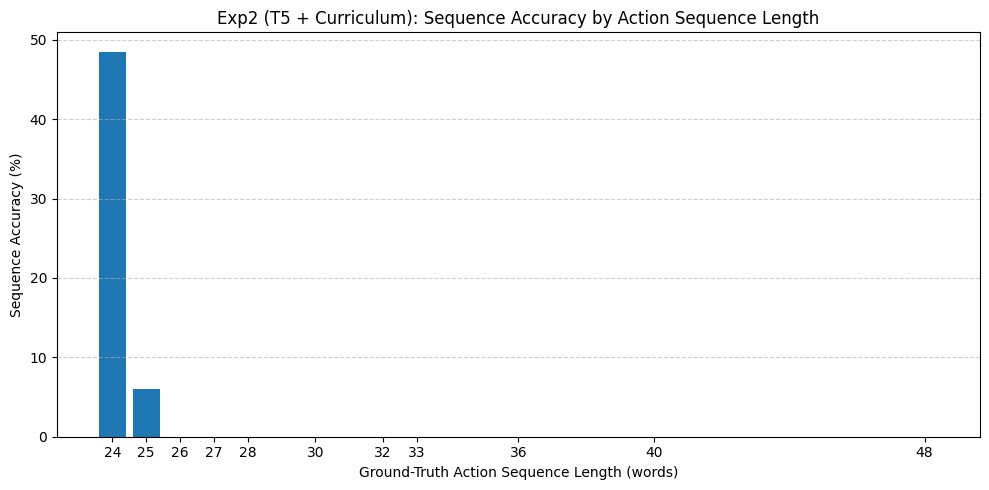

In [ ]:
run_exp2_curriculum_only()

Exp2 train size: 16990

=== Example training instances (complex input-side CoT) ===
[TRAIN COMPLEX 0] COMMAND : jump around right twice after look left thrice
[TRAIN COMPLEX 0] INPUT   : translate command to actions: jump around right twice after look left thrice Reasoning: we decompose the command into simpler sub-commands and modifiers.  "after" means we execute "look left thrice" first and then "jump around right twice".  'around right' means repeatedly turning right and applying the base action in a loop.  'twice' means repeating the described movement pattern two times.  'thrice' means repeating the described movement pattern three times.  The primitive verbs jump, look map directly to their atomic movement actions.
[TRAIN COMPLEX 0] TARGET  : I_TURN_LEFT I_LOOK I_TURN_LEFT I_LOOK I_TURN_LEFT I_LOOK I_TURN_RIGHT I_JUMP I_TURN_RIGHT I_JUMP I_TURN_RIGHT I_JUMP I_TURN_RIGHT I_JUMP I_TURN_RIGHT I_JUMP I_TURN_RIGHT I_JUMP I_TURN_RIGHT I_JUMP I_TURN_RIGHT I_JUMP
---
[TRAIN COMPLEX 1] CO

/tmp/ipython-input-1719646994.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and device.type == "cuda"))
/tmp/ipython-input-1719646994.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(use_amp and device.type == "cuda")):



=== Stage 1: act_len <= 10 | examples=9220 | steps=5000 ===
Stage 1 | step   1000/5000 | global   1000/20000 | loss=0.1540
Stage 1 | step   2000/5000 | global   2000/20000 | loss=0.0106
Stage 1 | step   3000/5000 | global   3000/20000 | loss=0.0063
Stage 1 | step   4000/5000 | global   4000/20000 | loss=0.0047
Stage 1 | step   5000/5000 | global   5000/20000 | loss=0.0039

=== Stage 2: act_len <= 14 | examples=13150 | steps=5000 ===
Stage 2 | step   1000/5000 | global   6000/20000 | loss=0.0038
Stage 2 | step   2000/5000 | global   7000/20000 | loss=0.0031
Stage 2 | step   3000/5000 | global   8000/20000 | loss=0.0030
Stage 2 | step   4000/5000 | global   9000/20000 | loss=0.0020
Stage 2 | step   5000/5000 | global  10000/20000 | loss=0.0017

=== Stage 3: act_len <= 18 | examples=15438 | steps=5000 ===
Stage 3 | step   1000/5000 | global  11000/20000 | loss=0.0035
Stage 3 | step   2000/5000 | global  12000/20000 | loss=0.0019
Stage 3 | step   3000/5000 | global  13000/20000 | loss=0.0

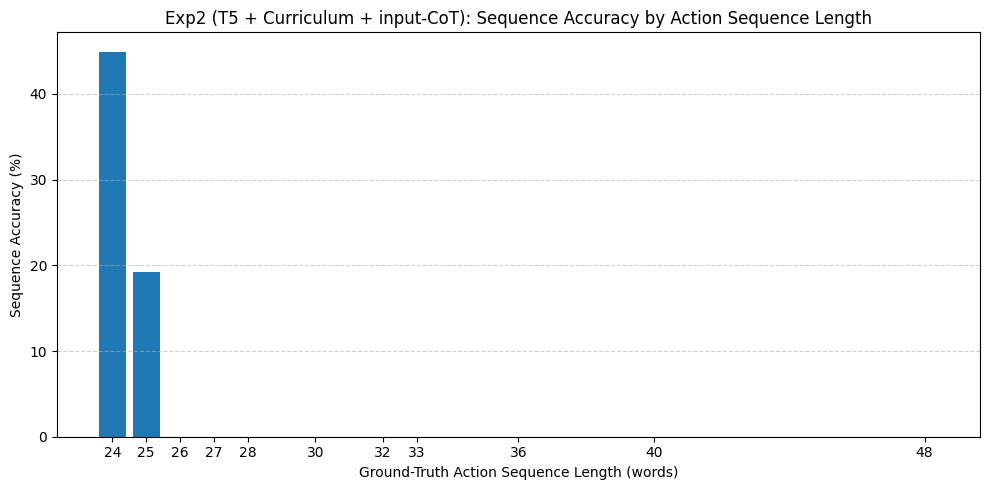


=== Correct predictions (up to 2) ===
INPUT : translate command to actions: run around left twice and run around right
GOLD  : I_TURN_LEFT I_RUN I_TURN_LEFT I_RUN I_TURN_LEFT I_RUN I_TURN_LEFT I_RUN I_TURN_LEFT I_RUN I_TURN_LEFT I_RUN I_TURN_LEFT I_RUN I_TURN_LEFT I_RUN I_TURN_RIGHT I_RUN I_TURN_RIGHT I_RUN I_TURN_RIGHT I_RUN I_TURN_RIGHT I_RUN
PRED  : I_TURN_LEFT I_RUN I_TURN_LEFT I_RUN I_TURN_LEFT I_RUN I_TURN_LEFT I_RUN I_TURN_LEFT I_RUN I_TURN_LEFT I_RUN I_TURN_LEFT I_RUN I_TURN_LEFT I_RUN I_TURN_RIGHT I_RUN I_TURN_RIGHT I_RUN I_TURN_RIGHT I_RUN I_TURN_RIGHT I_RUN
ACTIONS (parsed): I_TURN_LEFT I_RUN I_TURN_LEFT I_RUN I_TURN_LEFT I_RUN I_TURN_LEFT I_RUN I_TURN_LEFT I_RUN I_TURN_LEFT I_RUN I_TURN_LEFT I_RUN I_TURN_LEFT I_RUN I_TURN_RIGHT I_RUN I_TURN_RIGHT I_RUN I_TURN_RIGHT I_RUN I_TURN_RIGHT I_RUN
---
INPUT : translate command to actions: look around left twice and jump around right
GOLD  : I_TURN_LEFT I_LOOK I_TURN_LEFT I_LOOK I_TURN_LEFT I_LOOK I_TURN_LEFT I_LOOK I_TURN_LEFT I_L

{'seq_acc': 6.045918367346939, 'tok_acc': 69.55280767108168}

In [ ]:
run_exp2_curriculum_and_cot()